# Admission dataset - Exploratory data analysis
The goal of this project is to clean and visualize applicants datasets, demostrating mastery of EDA (Exploratory data analysis).

### Import the neccesary libraries to load, explore,analyze and visualize the Admission dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset with error handling

In [2]:
try:
    data = pd.read_csv("college_Admission.csv")
    print("Dataset loaded successfully.")

except FileNotFoundError:
    print("Error: The dataset file was not found.")

except pd.errors.ParserError:
    print("Error: The dataset contains malformed or incorrectly formatted data.")

except Exception as e:
    print("An unexpected error occurred:", e)

Dataset loaded successfully.


### Analyze/Clean the dataset

In [3]:
data.head()

,student_id,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
0,250.99,17,other,general,odisha,management,cet,30,95.58,2,0.387,admitted,yes
1,250.99,20,other,ews,gujarat,agriculture,none,0,75.45,2,0.221,rejected,no
2,250.99,19,female,sc,uttar pradesh,pharmacy,cet,120,75.36,10,0.446,rejected,no
3,250.99,18,male,ews,meghalaya,arts,cet,179,52.49,2,0.174,admitted,no
4,250.99,18,male,sc,rajasthan,engineering,jee,295,92.48,7,0.634,admitted,yes


In [4]:
data.shape

(25000, 13)

In [5]:
data.columns

Index(['student_id', 'age', 'gender', 'category', 'state', 'preferred_stream',
       'entrance_exam', 'entrance_score', 'board_percentage',
       'extracurricular_score', 'admission_probability', 'admission_status',
       'scholarship_eligibility'],
      dtype='object')

In [6]:
data.isnull().sum()

student_id                 0
age                        0
gender                     0
category                   0
state                      0
preferred_stream           0
entrance_exam              0
entrance_score             0
board_percentage           0
extracurricular_score      0
admission_probability      0
admission_status           0
scholarship_eligibility    0
dtype: int64

In [7]:
data.duplicated().sum()

0

In [8]:
data.describe()

,student_id,age,entrance_score,board_percentage,extracurricular_score,admission_probability
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,18.492440,77.879760,75.028014,4.990920,0.323997
std,7212.732314,1.116205,120.356125,14.438767,3.158942,0.142427
min,250.990000,17.000000,0.000000,50.440000,0.000000,0.041990
25%,6250.750000,17.000000,0.000000,62.550000,2.000000,0.219000
50%,12500.500000,18.000000,20.000000,75.070000,5.000000,0.319000
75%,18750.250000,19.000000,126.000000,87.640000,8.000000,0.419000
max,24750.010000,20.000000,634.000000,99.530000,10.000000,0.731010


In [9]:
data.dtypes

student_id                 float64
age                          int64
gender                      object
category                    object
state                       object
preferred_stream            object
entrance_exam               object
entrance_score               int64
board_percentage           float64
extracurricular_score        int64
admission_probability      float64
admission_status            object
scholarship_eligibility     object
dtype: object

### Check Inconsistent Values

In [10]:
data["gender"].unique()

array(['other', 'female', 'male'], dtype=object)

In [11]:
data["category"].unique()

array(['general', 'ews', 'sc', 'obc', 'st'], dtype=object)

In [12]:
data["state"].unique()

array(['odisha', 'gujarat', 'uttar pradesh', 'meghalaya', 'rajasthan',
       'himachal pradesh', 'nagaland', 'tamil nadu', 'telangana',
       'jharkhand', 'goa', 'madhya pradesh', 'sikkim', 'maharashtra',
       'assam', 'tripura', 'haryana', 'andhra pradesh', 'karnataka',
       'kerala', 'arunachal pradesh', 'chhattisgarh', 'punjab', 'mizoram',
       'bihar', 'manipur'], dtype=object)

In [13]:
data["preferred_stream"].unique()

array(['management', 'agriculture', 'pharmacy', 'arts', 'engineering',
       'architecture', 'medical', 'science', 'law',
       'computer applications', 'nursing', 'commerce'], dtype=object)

In [14]:
data["entrance_exam"].unique()

array(['cet', 'none', 'jee', 'neet'], dtype=object)

In [15]:
data["admission_status"].unique()

array(['admitted', 'rejected'], dtype=object)

In [16]:
data["scholarship_eligibility"].unique()

array(['yes', 'no'], dtype=object)

### Checking for outliers using Visual method (boxplot)

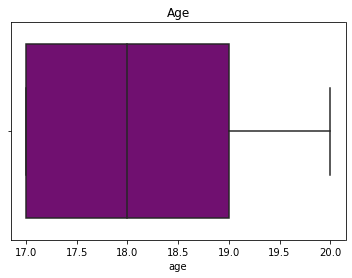

In [17]:
sns.boxplot(x=data["age"], color='purple')
plt.title("Age")
plt.show()

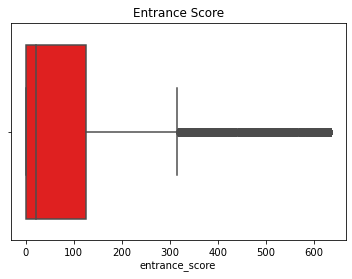

In [18]:
sns.boxplot(x=data["entrance_score"], color="red")
plt.title("Entrance Score")
plt.show()

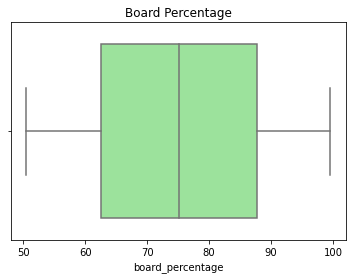

In [19]:
sns.boxplot(x=data["board_percentage"], color="lightgreen")
plt.title("Board Percentage")
plt.show()


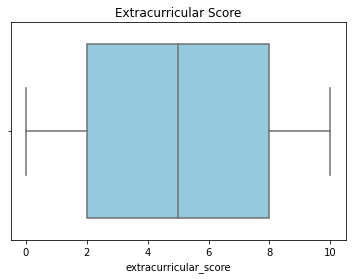

In [20]:
sns.boxplot(x=data["extracurricular_score"], color="skyblue")
plt.title("Extracurricular Score")
plt.show()


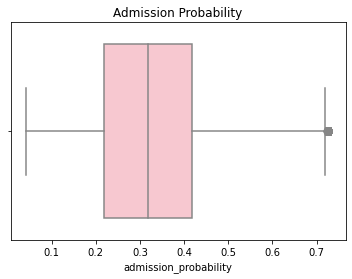

In [21]:
sns.boxplot(x=data["admission_probability"], color="pink")
plt.title("Admission Probability")
plt.show()

### Checking for outliers using Statistical method (Interquatile Range)

In [22]:
Q1 = data["age"]. quantile(0.25)
Q3 = data["age"]. quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower bound:", lower_bound)
print ("Upper bound:", upper_bound)

outliers = data[(data["age"] < lower_bound) |  (data["age"] > upper_bound)] 
print("Number of outliers:", len(outliers))

Lower bound: 14.0
Upper bound: 22.0
Number of outliers: 0


Using the IQR method, no outlier was found in the age column.

In [23]:
Q1 = data["entrance_score"]. quantile(0.25)
Q3 = data["entrance_score"]. quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower bound:", lower_bound)
print ("Upper bound:", upper_bound)

outliers = data[(data["entrance_score"] < lower_bound) |  (data["entrance_score"] > upper_bound)] 
print("Number of outliers:", len(outliers))

outliers

Lower bound: -189.0
Upper bound: 315.0
Number of outliers: 1156


,student_id,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
7,250.99,19,other,sc,nagaland,medical,neet,333,65.74,3,0.39200,rejected,no
12,250.99,19,female,ews,tamil nadu,medical,neet,358,89.23,6,0.63400,admitted,yes
18,250.99,20,male,sc,odisha,medical,neet,634,94.99,6,0.73101,admitted,yes
25,250.99,19,male,ews,tripura,medical,neet,574,57.52,10,0.62200,admitted,yes
40,250.99,17,other,st,meghalaya,medical,neet,385,70.08,0,0.40500,rejected,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24890,24750.01,20,other,ews,chhattisgarh,medical,neet,615,82.46,4,0.72200,admitted,no
24916,24750.01,18,other,st,haryana,medical,neet,370,59.42,8,0.46200,admitted,yes
24930,24750.01,19,female,sc,madhya pradesh,medical,neet,402,96.89,7,0.73101,rejected,no
24951,24750.01,19,other,obc,uttar pradesh,medical,neet,634,60.92,5,0.63100,rejected,no


Using the IQR method, 1,156 outliers were detected in the entrance exam column.The identified outliers were values above 315, and the first few outlier records were displayed to further understand their distribution in the dataset.


In [24]:
Q1 = data["board_percentage"]. quantile(0.25)
Q3 = data["board_percentage"]. quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower bound:", lower_bound)
print ("Upper bound:", upper_bound)

outliers = data[(data["board_percentage"] < lower_bound) |  (data["board_percentage"] > upper_bound)] 
print("Number of outliers:", len(outliers))

Lower bound: 24.914999999999992
Upper bound: 125.275
Number of outliers: 0


Using the IQR method, no outlier was found in the board_percentage column.

In [25]:
Q1 = data["extracurricular_score"]. quantile(0.25)
Q3 = data["extracurricular_score"]. quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower bound:", lower_bound)
print ("Upper bound:", upper_bound)

outliers = data[(data["extracurricular_score"] < lower_bound) |  (data["extracurricular_score"] > upper_bound)] 
print("Number of outliers:", len(outliers))

Lower bound: -7.0
Upper bound: 17.0
Number of outliers: 0


Using the IQR method, no outlier was found in the extracurricular_score column.

In [26]:
Q1 = data["admission_probability"]. quantile(0.25)
Q3 = data["admission_probability"]. quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower bound:", lower_bound)
print ("Upper bound:", upper_bound)

outliers = data[(data["admission_probability"] < lower_bound) |  (data["admission_probability"] > upper_bound)] 
print("Number of outliers:", len(outliers))

outliers

Lower bound: -0.08099999999999999
Upper bound: 0.719
Number of outliers: 286


,student_id,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
18,250.99,20,male,sc,odisha,medical,neet,634,94.99,6,0.73101,admitted,yes
65,250.99,18,female,st,andhra pradesh,medical,neet,629,99.53,8,0.73101,admitted,yes
121,250.99,19,male,ews,assam,medical,neet,634,93.19,9,0.73101,admitted,yes
238,250.99,18,female,ews,telangana,medical,neet,634,87.16,1,0.72200,admitted,yes
361,362.00,20,other,sc,chhattisgarh,medical,neet,634,86.87,6,0.73101,admitted,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24742,24743.00,20,female,general,odisha,medical,neet,536,99.20,6,0.73101,admitted,yes
24775,24750.01,19,other,sc,manipur,medical,neet,634,84.91,7,0.73101,admitted,no
24815,24750.01,17,female,st,goa,medical,neet,564,99.21,3,0.73101,rejected,no
24890,24750.01,20,other,ews,chhattisgarh,medical,neet,615,82.46,4,0.72200,admitted,no


Using the IQR method,286 outliers were detected in the admission_probability column.The identified outliers were values above 0.719, and the first few outlier records were displayed for further examination.

### Handling outliers

#### entrance_score
The entrance_exam column contains 1,156 potential outliers out of 25,000 records. Removing them arbitrarily could produce misleading results by eliminating legitimate variability. Since different exam types may have different scoring systems and ranges, I am investigating their score distributions to determine whether these values are valid before deciding how to handle them.


In [27]:
data.groupby("entrance_exam")["entrance_score"].agg(
    ["count", "min", "max", "mean", "median", "std"]
).round(2)

,count,min,max,mean,median,std
entrance_exam,,,,,,
cet,10433,0,199,99.97,101,58.08
jee,1245,0,299,146.50,147,84.55
neet,2034,0,634,354.78,357,201.65
none,11288,0,0,0.00,0,0.00


The table shows that each entrance examination has a different scoring range. Excluding applicants who did not take an entrance exam (none), NEET has the highest scoring range, followed by JEE and CET. The IQR method initially identified some entrance scores as outliers when all examinations were considered together. However, these values are relevant to the analysis because the examinations have different scoring scales. Therefore, the identified outliers were not removed, as they may represent valid and meaningful observations in the dataset.


#### admission_probability
The admission_probability column contains 286 potential outliers out of 25,000 records. Since these values are within the valid probability range and many correspond with relevant applicant characteristics such as entrance scores, board percentages, and admission status, removing them arbitrarily could eliminate meaningful information. Therefore, the outliers are retained for further analysis rather than treated as errors.


In [28]:
outliers[
    [
        "preferred_stream",
        "entrance_exam",
        "entrance_score",
        "board_percentage",
        "extracurricular_score",
        "admission_probability",
        "admission_status",
        "scholarship_eligibility"
    ]
].sort_values(
    by="admission_probability",
    ascending=False
)

,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
18,medical,neet,634,94.99,6,0.73101,admitted,yes
15705,medical,neet,520,92.27,5,0.73101,rejected,no
14256,medical,neet,634,87.29,6,0.73101,admitted,yes
14348,medical,neet,634,87.97,2,0.73101,admitted,yes
14505,medical,neet,376,98.52,7,0.73101,admitted,yes
...,...,...,...,...,...,...,...,...
19797,medical,neet,280,98.38,10,0.72100,rejected,no
7137,medical,neet,577,83.42,5,0.72100,rejected,no
6662,medical,neet,540,81.75,7,0.72100,rejected,no
13784,medical,neet,627,76.20,6,0.72100,admitted,no


The outliers represent valid applicant profiles with varying scores and admission outcomes. Removing them could eliminate meaningful information and hinder the analysis of factors influencing admission outcomes. Therefore, they are retained for further analysis.


### Computing Acceptance Rate 

In [29]:
acceptance_rate = data["admission_status"].value_counts(normalize=True).mul(100).round(2)

for status, percentage in acceptance_rate.items():
    print(f"{status.capitalize()}: {percentage}%")
acceptance_rate = (data['admission_status'] == 'admitted').mean() * 100

Rejected: 67.39%
Admitted: 32.61%


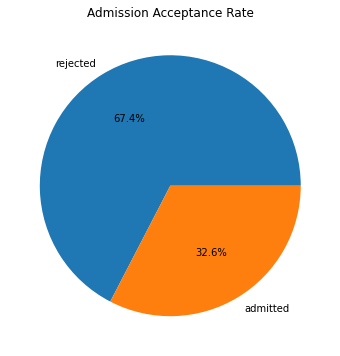

In [30]:
admission_counts = data["admission_status"].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(
    admission_counts,
    labels=admission_counts.index,
    autopct="%1.1f%%"
)

plt.title("Admission Acceptance Rate")
plt.show()

It shows that 32.61% were accepted and 67.39% were rejected.This tells us that the rejection rate is higher than the acceptance rate due to some factors.

In [31]:
average_scores = data.groupby("admission_status")[
    ["entrance_score", "board_percentage",
     "extracurricular_score", "admission_probability"]
].mean().round(2)

In [32]:
average_scores

,entrance_score,board_percentage,extracurricular_score,admission_probability
admission_status,,,,
admitted,106.92,79.70,5.55,0.39
rejected,63.83,72.77,4.72,0.29


The comparison shows that admitted applicants generally have higher average entrance_score, board_percentage, extracurricular_score, and admission_probability than rejected applicants. This suggests that stronger academic performance, extracurricular performance, and higher admission probability are associated with a greater likelihood of admission.


### Gender Ratios

In [33]:
gender_counts = data["gender"].value_counts()

print(
    gender_counts["other"],
    ":",
    gender_counts["male"],
    ":",
    gender_counts["female"]
)

8387 : 8364 : 8249


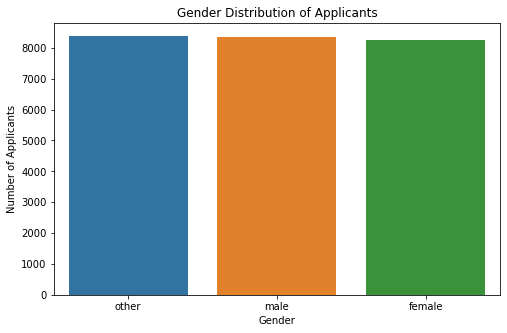

In [34]:
gender_counts = data["gender"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=gender_counts.index, y=gender_counts.values)

plt.title("Gender Distribution of Applicants")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")
plt.show()

In [35]:
gender_admission = pd.crosstab(
    data["gender"],
    data["admission_status"],
    normalize="index"
).mul(100).round(2)

gender_admission

admission_status,admitted,rejected
gender,,
female,32.69,67.31
male,32.01,67.99
other,33.12,66.88


The admission rates are relatively similar across genders, with 32.69% of females, 32.01% of males, and 33.12% of other applicants admitted. The small differences suggest that gender has a limited association with admission outcomes in this dataset.


### Top 5 Programs

In [36]:
top_5_programs = data["preferred_stream"].value_counts().head(5)

top_5_percentage = (
    data["preferred_stream"].value_counts(normalize=True).head(5).mul(100).round(2)
)
data['preferred_stream'] = data['preferred_stream'].str.title()
print("Top 5 Programs by Demand:")
for program, count in top_5_programs.items():
    print(f"{program}: {count} applicants ({top_5_percentage[program]}%)")


Top 5 Programs by Demand:
management: 2163 applicants (8.65%)
arts: 2135 applicants (8.54%)
nursing: 2118 applicants (8.47%)
architecture: 2102 applicants (8.41%)
agriculture: 2099 applicants (8.4%)


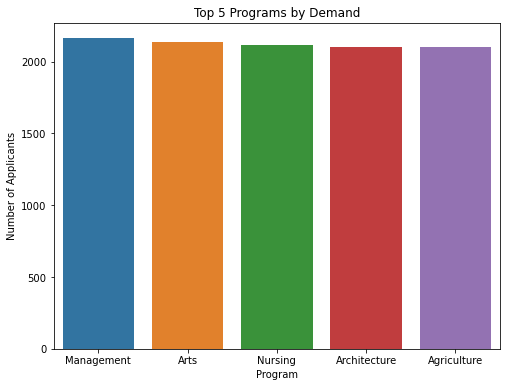

In [37]:
top_programs = data["preferred_stream"].value_counts().head(5)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_programs.index, y=top_programs.values)

plt.title("Top 5 Programs by Demand")
plt.xlabel("Program")
plt.ylabel("Number of Applicants")
plt.show()

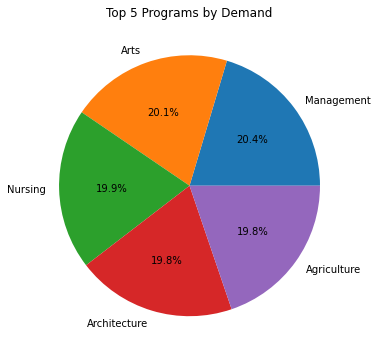

In [38]:
top_programs = data["preferred_stream"].value_counts().head(5)

percentages = (top_programs / len(data)) * 100

plt.figure(figsize=(8, 6))
plt.pie(
    percentages,
    labels=top_programs.index,
    autopct="%1.1f%%"
)

plt.title("Top 5 Programs by Demand")
plt.show()

The top five programs by applicant demand are Management (2,163 applicants), Arts (2,135), Nursing (2,118), Architecture (2,102), and Agriculture (2,099). Management has the highest demand, accounting for 8.65% of all applicants, while the other four programs each account for approximately 8.4%–8.54%.


### Insight Generation

A summary of the key findings obtained from the Exploratory Data Analysis (EDA) of the dataset. The findings highlight the acceptance rate, gender ratio, and the top five preferred programmes based on applicant demand.

In [39]:
print("INSIGHTS\n")

print(f"• The acceptance rate was {acceptance_rate:.2f}%.")
print(f"• The gender ratio was "
      f"Female: {gender_counts['female']}, "
      f"Male: {gender_counts['male']}, "
      f"Other: {gender_counts['other']}.")

print("• The top 5 programs by demand were:")
print(data['preferred_stream'].value_counts().head(5))

INSIGHTS

• The acceptance rate was 32.61%.
• The gender ratio was Female: 8249, Male: 8364, Other: 8387.
• The top 5 programs by demand were:
Management      2163
Arts            2135
Nursing         2118
Architecture    2102
Agriculture     2099
Name: preferred_stream, dtype: int64


### Summary Report

In [40]:
summary = pd.DataFrame({
    'Finding': [
        'Acceptance Rate',
        'Gender Ratio',
        'Top 5 Programs by Demand'
    ],
    'Result': [
        f'{acceptance_rate:.2f}%',
        f"Female: {gender_counts['female']}, Male: {gender_counts['male']}, Other: {gender_counts['other']}",
        ', '.join(data['preferred_stream'].value_counts().head(5).index.str.title())
    ]
})

In [41]:
summary

,Finding,Result
0,Acceptance Rate,32.61%
1,Gender Ratio,"Female: 8249, Male: 8364, Other: 8387"
2,Top 5 Programs by Demand,"Management, Arts, Nursing, Architecture, Agric..."


In [42]:
summary.to_csv('EDA_Summary_Report.csv', index=False)

### AI Feauture (Rule-based)

The Admission Data Explorer includes a simple rule-based feature that turns the results of the data analysis into short, story-like insights. Instead of recalculating the data, it uses the values already obtained during the analysis and applies simple thresholds and text templates to describe important findings such as the admission rate, most common gender group, popular programmes, and differences in entrance scores.This makes the results easier to understand while keeping the feature simple and transparent.

In [43]:
print("RULE-BASED INSIGHTS\n")

# Admission story
if acceptance_rate < 30:
    print(
        f"Out of all the applicants, only {acceptance_rate:.2f}% were admitted. "
        "This shows that admission was highly competitive."
    )

elif acceptance_rate < 50:
    print(
        f"Looking at the admission results, {acceptance_rate:.2f}% of applicants "
        "were admitted, meaning fewer than half of the applicants gained admission."
    )

else:
    print(
        f"The data shows that {acceptance_rate:.2f}% of applicants were admitted. "
        "This means more than half of the applicants gained admission."
    )


# Gender story
largest_gender = gender_counts.idxmax()

print(
    f"\nAmong the applicants, the {largest_gender} group had the highest number "
    f"of applicants, with {gender_counts.max():,} students."
)


# Programme story
top_program = top_programs.index[0]
top_program_count = top_programs.iloc[0]

print(
    f"\nWhen we look at programme preferences, {top_program} was the most popular "
    f"choice, attracting {top_program_count:,} applicants."
)


# Entrance score story
admitted_score = average_scores.loc['admitted', 'entrance_score']
rejected_score = average_scores.loc['rejected', 'entrance_score']

if admitted_score > rejected_score:
    print(
        f"\nThe data also shows a difference in entrance scores. "
        f"Applicants who were admitted had an average score of {admitted_score:.2f}, "
        f"compared with {rejected_score:.2f} for rejected applicants."
    )

RULE-BASED INSIGHTS

Looking at the admission results, 32.61% of applicants were admitted, meaning fewer than half of the applicants gained admission.

Among the applicants, the other group had the highest number of applicants, with 8,387 students.

When we look at programme preferences, Management was the most popular choice, attracting 2,163 applicants.

The data also shows a difference in entrance scores. Applicants who were admitted had an average score of 106.92, compared with 63.83 for rejected applicants.
